In [3]:
import numpy as np
import pandas as pd
import plotly.express as px

In [5]:
data = {
    "Order_id" : np.arange(1,21),
    "Region" : ["North","South","East","West"]*5,
    "Category": ["Electronics", "Clothing", "Furniture", "Electronics", "Clothing"] * 4,
    "Sales": np.random.randint(5000, 20000, 20),
    "Profit": np.random.randint(500, 5000, 20),  
    "Quantity": np.random.randint(1, 10, 20) 
}

df = pd.DataFrame(data)
df


,Order_id,Region,Category,Sales,Profit,Quantity
0,1,North,Electronics,10916,2208,6
1,2,South,Clothing,10280,4496,4
2,3,East,Furniture,8597,3307,9
3,4,West,Electronics,9302,984,7
4,5,North,Clothing,9590,1775,6
5,6,South,Electronics,11866,4185,6
6,7,East,Clothing,7367,1356,4
7,8,West,Furniture,18870,2555,9
8,9,North,Electronics,16243,2185,4
9,10,South,Clothing,18046,4115,3


In [7]:
df.head()


,Order_id,Region,Category,Sales,Profit,Quantity
0,1,North,Electronics,10916,2208,6
1,2,South,Clothing,10280,4496,4
2,3,East,Furniture,8597,3307,9
3,4,West,Electronics,9302,984,7
4,5,North,Clothing,9590,1775,6


In [9]:
df.shape

(20, 6)

In [11]:
df.columns

Index(['Order_id', 'Region', 'Category', 'Sales', 'Profit', 'Quantity'], dtype='object')

In [12]:
df.describe()

,Order_id,Sales,Profit,Quantity
count,20.00000,20.000000,20.000000,20.00000
mean,10.50000,10603.350000,2640.700000,4.95000
std,5.91608,3919.104453,1325.801489,2.32775
min,1.00000,5957.000000,518.000000,1.00000
25%,5.75000,7265.250000,1861.250000,3.75000
50%,10.50000,9952.000000,2368.000000,5.00000
75%,15.25000,11541.250000,4029.500000,6.00000
max,20.00000,18870.000000,4906.000000,9.00000


In [13]:
df.isnull().sum()

Order_id    0
Region      0
Category    0
Sales       0
Profit      0
Quantity    0
dtype: int64

In [15]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
region_sales

,Region,Sales
0,East,48769
1,North,54689
2,South,53100
3,West,55509


In [16]:
category_profit = df.groupby("Category")["Profit"].sum().reset_index()
category_profit

,Category,Profit
0,Clothing,18951
1,Electronics,25323
2,Furniture,8540


In [17]:
top_sales = df.sort_values(by="Sales", ascending=False).head(5)
top_sales

,Order_id,Region,Category,Sales,Profit,Quantity
7,8,West,Furniture,18870,2555,9
9,10,South,Clothing,18046,4115,3
8,9,North,Electronics,16243,2185,4
18,19,East,Electronics,16033,4906,5
5,6,South,Electronics,11866,4185,6


In [18]:
df["Profit_Ratio"] = df["Profit"]/df["Sales"]
df.head()

,Order_id,Region,Category,Sales,Profit,Quantity,Profit_Ratio
0,1,North,Electronics,10916,2208,6,0.202272
1,2,South,Clothing,10280,4496,4,0.437354
2,3,East,Furniture,8597,3307,9,0.384669
3,4,West,Electronics,9302,984,7,0.105784
4,5,North,Clothing,9590,1775,6,0.185089


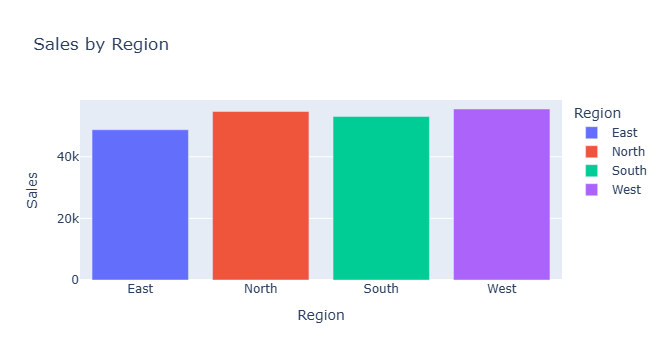

In [19]:
fig1 = px.bar(region_sales, 
              x="Region", 
              y="Sales", 
              title="Sales by Region",
              color="Region")

# Show plot
fig1.show()


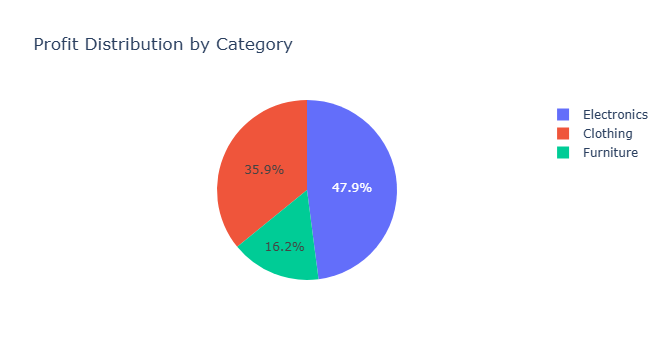

In [20]:
fig2 = px.pie(category_profit, 
              names="Category", 
              values="Profit", 
              title="Profit Distribution by Category")

# Show plot
fig2.show()


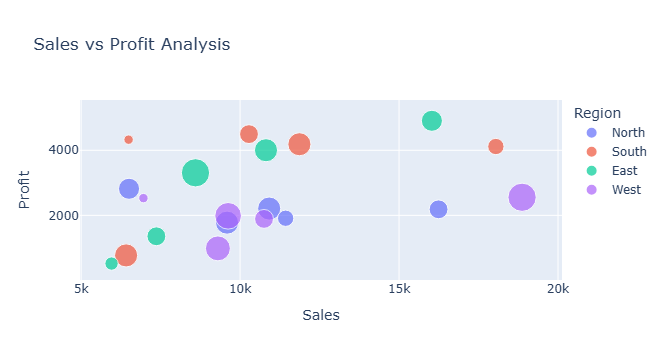

In [21]:
fig3 = px.scatter(df, 
                  x="Sales", 
                  y="Profit", 
                  color="Region",
                  size="Quantity",
                  title="Sales vs Profit Analysis")

# Show plot
fig3.show()


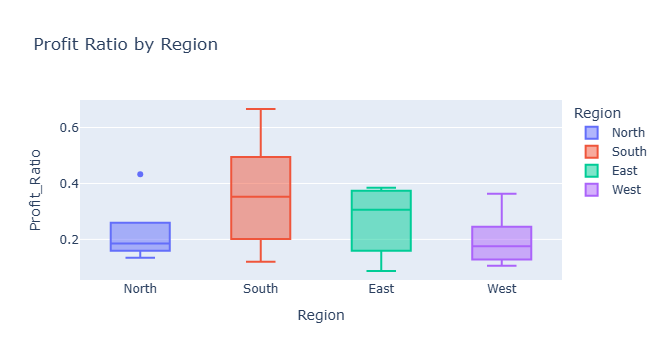

In [22]:
fig4 = px.box(df, 
              x="Region", 
              y="Profit_Ratio", 
              color="Region",
              title="Profit Ratio by Region")

# Show plot
fig4.show()


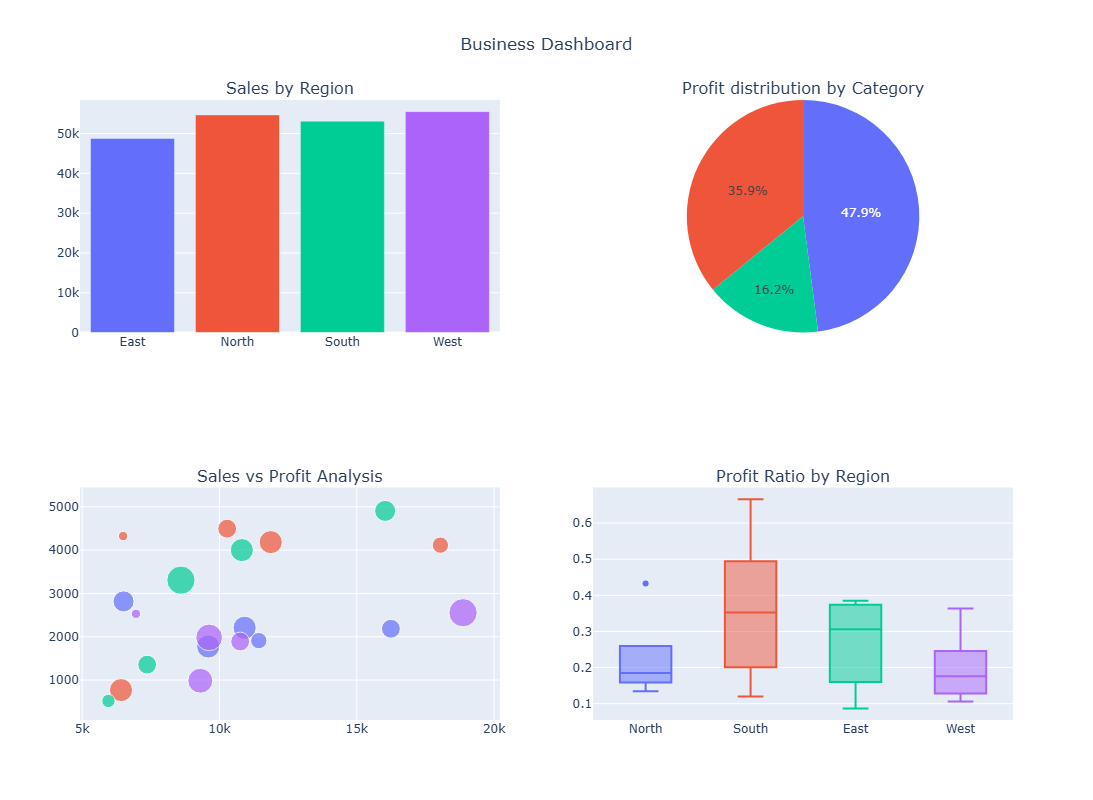

In [24]:
import plotly.express as px
from plotly.subplots import make_subplots

# Create individual figures
fig1 = px.bar(region_sales, x="Region", y="Sales", color="Region",
              title="Sales by Region")

fig2 = px.pie(category_profit, names="Category", values="Profit",
              title="Profit distribution by Category")

fig3 = px.scatter(df, x="Sales", y="Profit", color="Region", size="Quantity",
                  title="Sales vs Profit Analysis")

fig4 = px.box(df, x="Region", y="Profit_Ratio", color="Region",
              title="Profit Ratio by Region")

# Create subplot layout (IMPORTANT: specs defined)
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "domain"}],  # pie here
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Sales by Region",
        "Profit distribution by Category",
        "Sales vs Profit Analysis",
        "Profit Ratio by Region"
    )
)

# Add traces
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in fig3.data:
    fig.add_trace(trace, row=2, col=1)

for trace in fig4.data:
    fig.add_trace(trace, row=2, col=2)

# Clean layout
fig.update_layout(
    title="Business Dashboard",
    title_x=0.5,
    height=800,
    showlegend=False
)

fig.show()